 ## Imports and Setup

In [17]:
import pandas as pd
import numpy as np
# Scaling
from sklearn.preprocessing import MinMaxScaler
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# Plotting
import matplotlib.pyplot as plt
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import json

## Load Dataset

In [18]:
df = pd.read_csv(
    "../../data/processed/feature_engineered_unscaled.csv",
    parse_dates=[0],
    index_col=0
)

df = df.sort_index()
df.head()

,demand,demand_diff,lag_1,lag_48,rolling_mean_48,hour,day_of_week,month
timestamp,,,,,,,,
2023-01-02 00:00:00,21550,1817.0,19733.0,18995.0,21638.020833,0,0,1
2023-01-02 00:30:00,22238,688.0,21550.0,19730.0,21690.270833,0,0,1
2023-01-02 01:00:00,21894,-344.0,22238.0,19327.0,21743.750000,1,0,1
2023-01-02 01:30:00,21459,-435.0,21894.0,18589.0,21803.541667,1,0,1
2023-01-02 02:00:00,20926,-533.0,21459.0,17806.0,21868.541667,2,0,1


## Select Target Variable

In [19]:
target = "demand"

series = df[[target]].dropna()
series.head()

,demand
timestamp,
2023-01-02 00:00:00,21550
2023-01-02 00:30:00,22238
2023-01-02 01:00:00,21894
2023-01-02 01:30:00,21459
2023-01-02 02:00:00,20926


## Train-Test Split

In [20]:
SPLIT_RATIO = 0.8

split_idx = int(len(series) * SPLIT_RATIO)
SPLIT_TIMESTAMP = series.index[split_idx]

print(f"Official train-test split timestamp: {SPLIT_TIMESTAMP}")

Official train-test split timestamp: 2023-12-12 20:00:00


## Apply the Split

In [21]:
train_series = series.loc[:SPLIT_TIMESTAMP]
test_series = series.loc[SPLIT_TIMESTAMP:]

print("Train samples:", len(train_series))
print("Test samples:", len(test_series))

Train samples: 226965
Test samples: 60264


## Scale Time-Series Data

In [22]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
test_scaled = scaler.transform(test_series.values.reshape(-1, 1))
print(train_scaled.shape)
print(test_scaled.shape)

(226965, 1)
(60264, 1)


## Create Sequences for LSTM

In [23]:
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 48  # one day of half-hourly data

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)

## Verify LSTM Input Shape

In [24]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (226917, 48, 1)
y_train shape: (226917,)


## Design LSTM Model Architecture

In [25]:
model = Sequential([
    LSTM(
        units=50,
        activation="tanh",
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(1)
])

model.summary()


c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Deep Learning Model

In [26]:
model.compile(
    optimizer="adam",
    loss="mse"
)

## Callbacks


In [27]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Train the LSTM Model

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
5673/5673 ━━━━━━━━━━━━━━━━━━━━ 122s 21ms/step - loss: 0.0104 - val_loss: 0.0134
Epoch 2/50
5673/5673 ━━━━━━━━━━━━━━━━━━━━ 112s 20ms/step - loss: 0.0093 - val_loss: 0.0146
Epoch 3/50
5673/5673 ━━━━━━━━━━━━━━━━━━━━ 112s 20ms/step - loss: 0.0092 - val_loss: 0.0144
Epoch 4/50
5673/5673 ━━━━━━━━━━━━━━━━━━━━ 116s 20ms/step - loss: 0.0092 - val_loss: 0.0144
Epoch 5/50
5673/5673 ━━━━━━━━━━━━━━━━━━━━ 116s 20ms/step - loss: 0.0092 - val_loss: 0.0145
Epoch 6/50
5673/5673 ━━━━━━━━━━━━━━━━━━━━ 116s 20ms/step - loss: 0.0092 - val_loss: 0.0149


## Plot Learning Curves


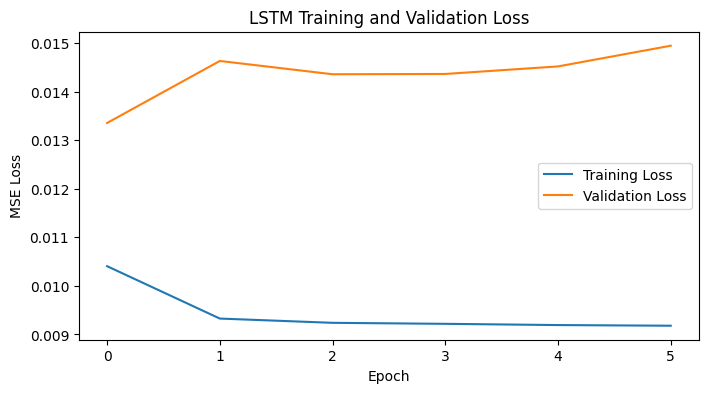

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

## Evaluate on Test Set

In [30]:
## Make Predictions
lstm_preds_scaled = model.predict(X_test)

# Inverse scaling
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))
mae = mean_absolute_error(y_test_actual, lstm_preds)

rmse, mae

1882/1882 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step


(np.float64(4067.5391452235726), 3191.6628698534237)

In [31]:
# Save metrics to a JSON file
lstm_results = {
    'model_name': 'LSTM',
    'rmse': float(rmse),
    'mae': float(mae)
}

with open('../results/lstm_metrics.json', 'w') as f:
    json.dump(lstm_results, f)

# Save predictions and actual values for the comparison plot
np.save('../results/lstm_preds.npy', lstm_preds[:100])
np.save('../results/actual_values.npy', y_test_actual[:100])

## Save the Model

In [32]:
model.save("lstm_model.keras")